In [1]:
pip install gradio tweepy snscrape transformers nltk spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install torch langdetect Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=b265f83dcb07e37f20a4aaf2dfc3858108f7d60e868ff53644b5d13f97a36777
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


**Import the model**

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the tokenizer and model
MODEL_DIR = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/saved_model"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

# Ensure the model is in evaluation mode
model.eval()


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

**Data Processing**

In [5]:
import re
import string
import nltk
import ast
from langdetect import detect
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

# Initialize necessary tools
english_stopwords = set(stopwords.words('english'))
factory = StemmerFactory()
sastrawi_stemmer = factory.create_stemmer()
wordnet_lemmatizer = WordNetLemmatizer()

# Load custom stopwords
with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/malaysian.txt', 'r', encoding='utf-8') as f:
    malay_stopwords = set(f.read().splitlines())
with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/cn_stopwords.txt', 'r', encoding='utf-8') as f:
    chinese_stopwords = set(f.read().splitlines())

# Combine all stopwords
all_stopwords = english_stopwords.union(malay_stopwords, chinese_stopwords)

# Load OOV dictionary
oov_dict = {}
with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/NLP OOV.txt', 'r') as file:
    for line in file:
        try:
            line_dict = ast.literal_eval("{" + line.strip() + "}")
            oov_dict.update(line_dict)
        except (ValueError, SyntaxError):
            print(f"Skipping invalid line: {line.strip()}")

def clean_text(text):
    """Clean the input text by removing unwanted characters."""
    text = re.sub(r'http\S+|www.\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)  # Remove mentions and hashtags
    text = re.sub(r'[^\x00-\x7f]', r'', text)  # Remove emojis and non-ASCII characters
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.lower()  # Convert to lowercase
    return text

def get_wordnet_pos(word):
    """Map POS tag from NLTK to WordNet POS tags."""
    from nltk.tag import pos_tag
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {'J': wordnet.ADJ, 'N': wordnet.NOUN, 'V': wordnet.VERB, 'R': wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_token(token):
    """Lemmatize or stem token based on its language."""
    lang = detect(token)
    if lang == 'en':
        pos = get_wordnet_pos(token)
        return wordnet_lemmatizer.lemmatize(token, pos=pos)
    elif lang == 'ms':
        return sastrawi_stemmer.stem(token)
    elif lang == 'zh':
        return token  # Chinese segmentation or stemming
    else:
        return token

def replace_slang(text, oov_dict):
    """Replace out-of-vocabulary words using the OOV dictionary."""
    return ' '.join([oov_dict.get(word, word) for word in text.split()])

def preprocess_text(text):
    """Preprocess the input text: clean, tokenize, remove stopwords, replace slang, and lemmatize."""
    # Clean the text
    cleaned_text = clean_text(text)

    # Replace slang and OOV words
    cleaned_text = replace_slang(cleaned_text, oov_dict)

    # Tokenize the cleaned text
    tokens = word_tokenize(cleaned_text)

    # Remove stopwords
    filtered_tokens = [word for word in tokens if word not in all_stopwords]

    # Lemmatize tokens
    lemmatized_tokens = [lemmatize_token(token) for token in filtered_tokens]

    return ' '.join(lemmatized_tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Skipping invalid line: ﻿";)": "winking face",
Skipping invalid line: "aura": "the vibe someone gives off, often used to describe how cool or badass someone is, with 'aura points' enhancing social appeal".
Skipping invalid line: "Bapak ah": ""Wow", "Oh My God" and "no way"",


**Sentiment Analysis and Results**

In [6]:
def predict_sentiment(text, neutral_threshold=0.3):
    """Predict sentiment of the given text."""
    preprocessed_text = preprocess_text(text)
    inputs = tokenizer(preprocessed_text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = logits.softmax(dim=-1)  # Convert logits to probabilities

    # Get probabilities for each class
    neg_prob = probabilities[0][0].item()
    pos_prob = probabilities[0][1].item()

    # Determine if the sentiment is Neutral
    if abs(neg_prob - pos_prob) < neutral_threshold:
        return "Neutral"
    else:
        sentiments = ["Negative", "Positive"]
        predicted_class = logits.argmax(dim=-1).item()
        return sentiments[predicted_class]

**Rojak Language Sentiment Analysis Testing GUI**

In [7]:
import gradio as gr

def gradio_predict(text):
    return predict_sentiment(text)

# Create the Gradio interface
iface = gr.Interface(fn=gradio_predict, inputs="text", outputs="text")

# Launch the interface
iface.launch()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a4d31368d498e4bf73.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
test_texts = [
    ("Makanan kat sini memang sedap gila, harga pun berpatutan!", "Positive"),
    ("Baju ni okay je, tapi tak rasa selesa sangat lah.", "Neutral"),
    ("Sistem komputer ni sangat slow, menyusahkan kerja!", "Negative"),
    ("View kat sini sangat cantik, worth it!", "Positive"),
    ("Kereta ni macam tak berbaloi, banyak masalah.", "Negative"),
    ("Produk ni okay lah, tapi expected lebih sikit.", "Neutral"),
    ("Memang puas hati dengan perkhidmatan dia, customer support bagus!", "Positive"),
    ("Banyak bug dalam app ni, sangat tak stabil.", "Negative"),
    ("Customer service dia okay, cuma agak lambat.", "Neutral"),
    ("Seronok sangat guna phone ni, takde masalah langsung!", "Positive"),
    ("Kafe ni best, tapi agak mahal sikit lah.", "Neutral"),
    ("Produk ni betul-betul teruk, langsung tak berfungsi!", "Negative"),
    ("Bila tengok harga, rasa macam berbaloi la jugak.", "Neutral"),
    ("I really love the ambiance here, perfect for hanging out!", "Positive"),
    ("I don't like this phone, the battery drains so fast.", "Negative"),
    ("The movie was decent, not the best, but still okay.", "Neutral"),
    ("Suka sangat dengan telefon baru ni, sangat laju!", "Positive"),
    ("Bilik air ni agak kotor, tak berapa selesa.", "Negative"),
    ("Kedai ni ada macam-macam, tapi agak mahal sikit.", "Negative"),
    ("Kawan-kawan saya semua suka produk ni, memang terbaik!", "Positive"),
    ("Baru beli telefon ni, cepat rosak, sangat kecewa.", "Negative")
]


In [10]:
# Define the function to calculate accuracy
def calculate_accuracy(predictions, true_labels):
    correct = sum([pred == true for pred, true in zip(predictions, true_labels)])
    accuracy = correct / len(true_labels)
    return accuracy

# Process the test texts and make predictions
test_texts_processed = [preprocess_text(text) for text, _ in test_texts]
inputs = tokenizer(test_texts_processed, return_tensors="pt", padding=True, truncation=True)

# Make predictions
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1).cpu().numpy()

# True labels (0 for Negative, 1 for Positive, 2 for Neutral if you change your model)
true_labels = [1 if label == "Positive" else 0 for _, label in test_texts]  # If the model only outputs Positive and Negative

# Calculate accuracy
accuracy = calculate_accuracy(predictions, true_labels)

# Output the predictions along with the true labels and accuracy
for (text, true_label), pred in zip(test_texts, predictions):
    print(f"Text: {text}")
    print(f"True Label: {true_label}")
    print(f"Predicted Sentiment: {'Positive' if pred == 1 else 'Negative'}")
    print("-" * 50)

print(f"Accuracy: {accuracy * 100:.2f}%")


Text: Makanan kat sini memang sedap gila, harga pun berpatutan!
True Label: Positive
Predicted Sentiment: Positive
--------------------------------------------------
Text: Baju ni okay je, tapi tak rasa selesa sangat lah.
True Label: Neutral
Predicted Sentiment: Positive
--------------------------------------------------
Text: Sistem komputer ni sangat slow, menyusahkan kerja!
True Label: Negative
Predicted Sentiment: Negative
--------------------------------------------------
Text: View kat sini sangat cantik, worth it!
True Label: Positive
Predicted Sentiment: Positive
--------------------------------------------------
Text: Kereta ni macam tak berbaloi, banyak masalah.
True Label: Negative
Predicted Sentiment: Negative
--------------------------------------------------
Text: Produk ni okay lah, tapi expected lebih sikit.
True Label: Neutral
Predicted Sentiment: Positive
--------------------------------------------------
Text: Memang puas hati dengan perkhidmatan dia, customer suppor


---


**Twitter Scrapping**





---



In [ ]:
pip install tweepy


In [ ]:
import tweepy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Initialize Tweepy API using Twitter v2 API
def initialize_tweepy_v2(bearer_token):
    """Initialize the Tweepy client for Twitter v2 API."""
    return tweepy.Client(bearer_token=bearer_token)

# Twitter API credentials
BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAABSMxgEAAAAA%2FNHYV3sYffuOhDA%2FazWIaMxPxbk%3DpFnRqdwQHoQ5eO5JS8t9UIY7Lu6BJDbDBzT1hpMhgL5d4CwRSR"
client = initialize_tweepy_v2(BEARER_TOKEN)

def analyze_sentiment(text):
    """
    Analyze the sentiment of a given text using the custom sentiment analysis model.
    :return: Sentiment prediction (Positive, Negative, or Neutral).
    """
    preprocessed_text = preprocess_text(text)  # Preprocess the text before passing it to the model

    inputs = tokenizer(preprocessed_text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = logits.softmax(dim=-1)  # Convert logits to probabilities

    # Get probabilities for each class
    neg_prob = probabilities[0][0].item()
    pos_prob = probabilities[0][1].item()

    # Determine if the sentiment is Neutral based on the threshold
    if abs(neg_prob - pos_prob) < 0.3:  # Threshold to determine Neutral
        return "Neutral"
    else:
        sentiments = ["Negative", "Positive"]
        predicted_class = logits.argmax(dim=-1).item()
        return sentiments[predicted_class]

# Fetch tweets using Tweepy v2 API
def get_tweets_tweepy_v2(query, count, client):
    """
    Fetch tweets using Twitter v2 API with Tweepy.
    :param query: Search query (e.g., hashtag, keywords).
    :param count: Number of tweets to fetch.
    :param client: Tweepy client object.
    :return: DataFrame containing tweets.
    """
    tweets = client.search_recent_tweets(query=query, max_results=count, tweet_fields=["created_at", "public_metrics"])
    tweet_data = []

    for tweet in tweets.data:
        tweet_data.append({
            "text": tweet.text,
            "date": tweet.created_at,
            "likes": tweet.public_metrics["like_count"],
            "comments": tweet.public_metrics["reply_count"]
        })

    return pd.DataFrame(tweet_data)


'\n# Fetch tweets using Tweepy v2 API\ndef get_tweets_tweepy_v2(query, count, client):\n    """\n    Fetch tweets using Twitter v2 API with Tweepy.\n    :param query: Search query (e.g., hashtag, keywords).\n    :param count: Number of tweets to fetch.\n    :param client: Tweepy client object.\n    :return: DataFrame containing tweets.\n    """\n    tweets = client.search_recent_tweets(query=query, max_results=count, tweet_fields=["created_at", "public_metrics"])\n    tweet_data = []\n\n    for tweet in tweets.data:\n        tweet_data.append({\n            "text": tweet.text,\n            "date": tweet.created_at,\n            "likes": tweet.public_metrics["like_count"],\n            "comments": tweet.public_metrics["reply_count"]\n        })\n\n    return pd.DataFrame(tweet_data)\n'

In [ ]:
import time
from tweepy import TooManyRequests

def fetch_tweets_with_rate_limit(query, count, client):
    """
    Fetch tweets with rate limit handling.
    :param query: The search query (can include hashtags, keywords, etc.).
    :param count: Number of tweets to fetch.
    :param client: The Tweepy client instance.
    :return: DataFrame containing tweets.
    """
    try:
        tweets_df = get_tweets_tweepy_v2(query, count, client)
    except TooManyRequests as e:
        # Get the rate limit reset time from the exception headers
        reset_time = int(e.response.headers.get("x-rate-limit-reset", time.time() + 60))
        wait_time = reset_time - time.time()
        print(f"Rate limit exceeded. Waiting for {wait_time} seconds.")
        time.sleep(wait_time)
        # Retry fetching tweets after rate limit reset
        tweets_df = get_tweets_tweepy_v2(query, count, client)
    return tweets_df


'\nimport time\nfrom tweepy import TooManyRequests\n\ndef fetch_tweets_with_rate_limit(query, count, client):\n    """\n    Fetch tweets with rate limit handling.\n    :param query: The search query (can include hashtags, keywords, etc.).\n    :param count: Number of tweets to fetch.\n    :param client: The Tweepy client instance.\n    :return: DataFrame containing tweets.\n    """\n    try:\n        tweets_df = get_tweets_tweepy_v2(query, count, client)\n    except TooManyRequests as e:\n        # Get the rate limit reset time from the exception headers\n        reset_time = int(e.response.headers.get("x-rate-limit-reset", time.time() + 60))\n        wait_time = reset_time - time.time()\n        print(f"Rate limit exceeded. Waiting for {wait_time} seconds.")\n        time.sleep(wait_time)\n        # Retry fetching tweets after rate limit reset\n        tweets_df = get_tweets_tweepy_v2(query, count, client)\n    return tweets_df\n  '

In [ ]:
# Fetch tweets
query = "Rosmah -is:retweet"
tweets_df = fetch_tweets_with_rate_limit(query, 50, client)
tweets_df["sentiment"] = tweets_df["text"].apply(analyze_sentiment)

# Display the tweets DataFrame
print(tweets_df)

                                                 text  \
0   "Saya  ingin mengucapkan syukur pada Datin Ser...   
1   Hormati keputusan mahkamah bebas Rosmah - Ahma...   
2   @Hancurzberkecai @anwaribrahim nak lepaskan am...   
3                             https://t.co/G9qkCuzpak   
4   @msianaffairs Anwar once said: “To him (Najib)...   
5   Can ALL Msians not pay taxes like the rich, po...   
6   The US$346mil lawsuit filed by 1Malaysia Devel...   
7   #Malaysian court has acquitted Rosmah Mansor, ...   
8   The development was confirmed by lawyer Villas...   
9   @501Awani @amer7211 lahanat kaki fitnah. Datin...   
10  Kes saman US$346 juta 1MDB terhadap Rosmah did...   
11  Lagi satu LHDN...kalau cukai M40 sampai ke lub...   
12  @MalaysiaGazette Rosmah Mansor aka Big mama Be...   
13  @nizar_hawari @YazidAiman4 @JatIkhwan Kirenye ...   
14  @RuleMaker101 @SyedAkramin Kes Musa Aman, AG w...   
15  Join now for more such profitable trades👉https...   
16  Mesti ramai akan salahkan A

<ipython-input-32-69f5c5644e4f>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='coolwarm')


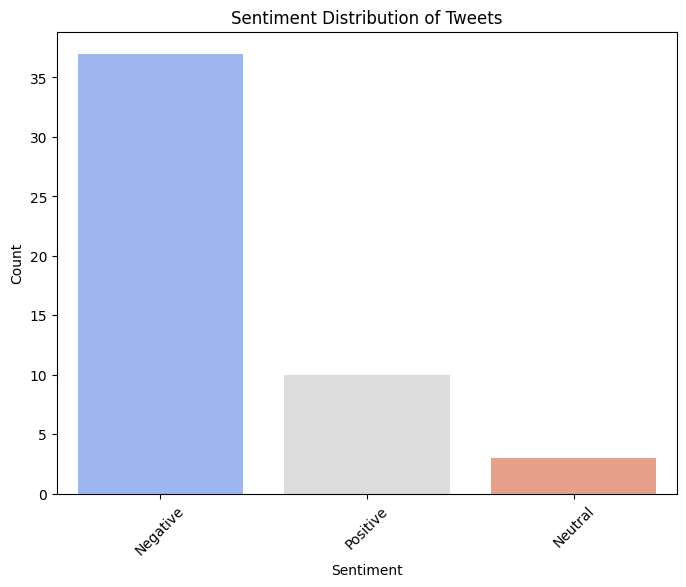

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of positive, negative, and neutral sentiments
sentiment_counts = tweets_df['sentiment'].value_counts()

# Plotting the sentiment distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='coolwarm')
plt.title("Sentiment Distribution of Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Positive Tweets Word Cloud')

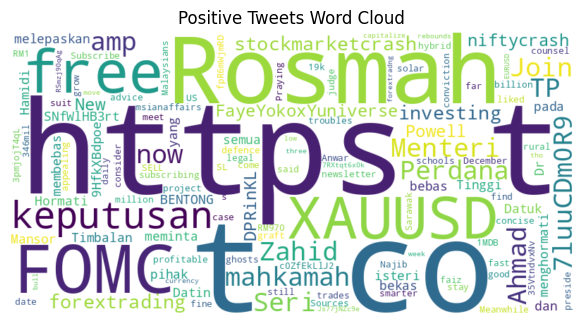

In [ ]:
from wordcloud import WordCloud

# Positive and Negative Text for Word Cloud Generation
positive_tweets = " ".join(tweets_df[tweets_df['sentiment'] == "Positive"]['text'])
negative_tweets = " ".join(tweets_df[tweets_df['sentiment'] == "Negative"]['text'])

# Generate Word Clouds
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_tweets)
wordcloud_negative = WordCloud(width=800, height=400, background_color='black').generate(negative_tweets)

# Plotting Word Clouds
plt.figure(figsize=(16, 12))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Tweets Word Cloud')

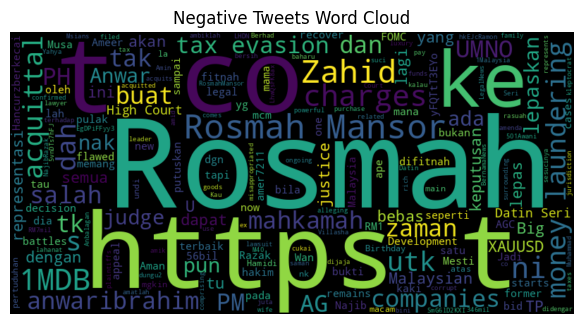

In [ ]:
plt.figure(figsize=(16, 12))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Tweets Word Cloud')

plt.show()

In [ ]:
tweets_df.to_csv("tweets_with_sentiment.csv", index=False)

# Download the file to your local machine
from google.colab import files
files.download("tweets_with_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---


**Streamlit Web Based Interface**

In [10]:
!pip install streamlit langdetect Sastrawi
!pip install pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.4 MB/s eta 0:00:00


In [11]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import tweepy
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import re
import string
import nltk
import ast
import time
from langdetect import detect
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Initialize necessary tools
english_stopwords = set(stopwords.words('english'))
factory = StemmerFactory()
sastrawi_stemmer = factory.create_stemmer()
wordnet_lemmatizer = WordNetLemmatizer()

# Load custom stopwords from Colab file path
with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/malaysian.txt', 'r', encoding='utf-8') as f:
    malay_stopwords = set(f.read().splitlines())
with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/cn_stopwords.txt', 'r', encoding='utf-8') as f:
    chinese_stopwords = set(f.read().splitlines())

# Combine all stopwords
all_stopwords = english_stopwords.union(malay_stopwords, chinese_stopwords)

# Load OOV dictionary from Colab file path
oov_dict = {}
with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/NLP OOV.txt', 'r') as file:
    for line in file:
        try:
            line_dict = ast.literal_eval("{" + line.strip() + "}")
            oov_dict.update(line_dict)
        except (ValueError, SyntaxError):
            print(f"Skipping invalid line: {line.strip()}")

# Load Model and Tokenizer
MODEL_DIR = "/content/drive/MyDrive/RojakLanguageSentimentAnalysis/saved_model"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval()

def clean_text(text):
    text = re.sub(r'http\S+|www.\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)  # Remove mentions and hashtags
    text = re.sub(r'[^\x00-\x7f]', r'', text)  # Remove emojis and non-ASCII characters
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.lower()  # Convert to lowercase
    return text

def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {'J': wordnet.ADJ, 'N': wordnet.NOUN, 'V': wordnet.VERB, 'R': wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_token(token):
    lang = detect(token)
    if lang == 'en':
        pos = get_wordnet_pos(token)
        return wordnet_lemmatizer.lemmatize(token, pos=pos)
    elif lang == 'ms':
        return sastrawi_stemmer.stem(token)
    elif lang == 'zh':
        return token  # Chinese segmentation or stemming
    else:
        return token

def replace_slang(text, oov_dict):
    return ' '.join([oov_dict.get(word, word) for word in text.split()])

def preprocess_text(text):
    cleaned_text = clean_text(text)
    cleaned_text = replace_slang(cleaned_text, oov_dict)
    tokens = word_tokenize(cleaned_text)
    filtered_tokens = [word for word in tokens if word not in all_stopwords]
    lemmatized_tokens = [lemmatize_token(token) for token in filtered_tokens]
    return ' '.join(lemmatized_tokens)

def analyze_sentiment(text):
    preprocessed_text = preprocess_text(text)
    inputs = tokenizer(preprocessed_text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = logits.softmax(dim=-1)  # Convert logits to probabilities

    # Get probabilities for each class
    neg_prob = probabilities[0][0].item()
    pos_prob = probabilities[0][1].item()

    # Determine if the sentiment is Neutral based on the threshold
    if abs(neg_prob - pos_prob) < 0.3:  # Threshold to determine Neutral
        return "Neutral", neg_prob, pos_prob
    else:
        sentiments = ["Negative", "Positive"]
        predicted_class = logits.argmax(dim=-1).item()
        return sentiments[predicted_class], neg_prob, pos_prob

# Initialize Tweepy
def initialize_tweepy_v2(bearer_token):
    return tweepy.Client(bearer_token=bearer_token)

BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAABSMxgEAAAAA%2FNHYV3sYffuOhDA%2FazWIaMxPxbk%3DpFnRqdwQHoQ5eO5JS8t9UIY7Lu6BJDbDBzT1hpMhgL5d4CwRSR"
client = initialize_tweepy_v2(BEARER_TOKEN)

def fetch_tweets_with_rate_limit(query, count, client):
    try:
        # Attempt to fetch tweets
        tweets = client.search_recent_tweets(query=query, max_results=count, tweet_fields=["created_at", "public_metrics"])
        tweet_data = [{"text": tweet.text, "date": tweet.created_at} for tweet in tweets.data]
        return pd.DataFrame(tweet_data)
    except tweepy.errors.TooManyRequests as e:
        # Handle rate limit error and wait for reset
        reset_time = e.response.headers.get('x-rate-limit-reset')
        if reset_time:
            reset_timestamp = int(reset_time)
            wait_time = reset_timestamp - int(time.time()) + 1  # Add 1 second to avoid hitting immediately after reset
            print(f"Rate limit exceeded. Retrying in {wait_time} seconds...")
            time.sleep(wait_time)  # Wait for rate limit reset
            return fetch_tweets_with_rate_limit(query, count, client)  # Retry fetching tweets

# Streamlit App
st.set_page_config(page_title="Rojak Language Sentiment Analysis", layout="wide")
st.title("Rojak Language Sentiment Analysis")

# Tabs for organization
tab1, tab2 = st.tabs(["Input Sentiment Analysis ⌨️", "Scraped Data Analysis 🐦"])

# Tab 1: Input Sentiment Analysis
with tab1:
    st.header("Analyze Custom Rojak Text")
    user_input = st.text_area("Enter text to analyze:", height=150)

    if st.button("🔍 Analyze sentiment"):
        if user_input.strip():
            sentiment, neg_prob, pos_prob = analyze_sentiment(user_input)

            # Define the color based on sentiment
            if sentiment == "Positive":
                color = "#28a745"  # Vibrant green
            elif sentiment == "Negative":
                color = "#dc3545"  # Vivid red
            else:  # Neutral
                color = "#ffc107"  # Bright amber

            # Display the result with color and probabilities
            st.markdown(
                f"""
                <div style="padding:10px; border: 2px solid {color}; border-radius:5px; background-color:{color};">
                    <p style="font-size:20px; font-weight:bold; color:white; text-align:center;">
                    Predicted Sentiment: <b>{sentiment}</b></p>
                    <p style="font-size:18px; color:white; text-align:center;">
                    Positive Probability: <b>{pos_prob*100:.2f}%</b><br>
                    Negative Probability: <b>{neg_prob*100:.2f}%</b></p>
                </div>
                """,
                unsafe_allow_html=True,
            )
        else:
            st.error("Please enter valid text!")

    # Predefined Examples
    st.subheader("Try with predefined examples")
    predefined_examples = [
        "Makanan kat sini memang sedap gila, harga pun berpatutan!",
        "Sistem komputer ni sangat slow, menyusahkan kerja!",
        "Produk ni okay lah, tapi expected lebih sikit."
    ]
    for example in predefined_examples:
        if st.button(example):
            sentiment = analyze_sentiment(example)
            st.write(f"Sentiment: {sentiment}")

# Tab 2: Scraped Data Analysis
with tab2:
    st.header("Analyze Tweets by Hashtag")
    hashtag = st.text_input("Enter hashtag to search tweets (e.g., #Example):")
    tweet_count = st.slider("Number of tweets to fetch", min_value=10, max_value=100, value=50)

    if st.button("Fetch and Analyze Tweets"):
        if hashtag.strip():
            tweets_df = fetch_tweets_with_rate_limit(hashtag, tweet_count, client)
            tweets_df["sentiment"], neg_prob, pos_prob = zip(*tweets_df["text"].apply(analyze_sentiment))

            st.write("All Tweets:")
            st.dataframe(tweets_df)

            # Sentiment Distribution Pie Chart
            sentiment_counts = tweets_df["sentiment"].value_counts()
            fig, ax = plt.subplots(figsize=(5, 5))  # Adjust the figure size
            sentiment_counts.plot.pie(
                autopct='%1.1f%%',
                colors=['#dc3545', '#28a745', '#ffc107'],
                ax=ax,
                textprops={'fontsize': 10}  # Adjust text size for better visibility
            )
            ax.set_ylabel("")
            ax.set_title("Sentiment Distribution", fontsize=14)
            st.pyplot(fig)

            # Word Clouds
            st.subheader("Word Clouds")
            positive_tweets = " ".join(tweets_df[tweets_df["sentiment"] == "Positive"]["text"])
            negative_tweets = " ".join(tweets_df[tweets_df["sentiment"] == "Negative"]["text"])
            wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_tweets)
            wordcloud_negative = WordCloud(width=800, height=400, background_color='black').generate(negative_tweets)

            col1, col2 = st.columns(2)
            with col1:
                st.subheader("Positive Sentiment Word Cloud")
                st.image(wordcloud_positive.to_array())
            with col2:
                st.subheader("Negative Sentiment Word Cloud")
                st.image(wordcloud_negative.to_array())

            # Download Button
            csv = tweets_df.to_csv(index=False)
            st.download_button(
                label="⬇️ Download Results",
                data=csv,
                file_name="tweets_with_sentiment.csv",
                mime="text/csv",
                help="Click to download the analyzed tweets as a CSV file."
            )
        else:
            st.error("Please enter a valid hashtag!")

# Theming (Optional)
st.sidebar.header("Settings")
dark_mode = st.sidebar.checkbox("Dark Mode", value=False)
# Apply dynamic dark mode styles
if dark_mode:
    st.markdown(
        """
        <style>
            body {
                background-color: #333;
                color: #fff;
            }
            .stButton>button {
                background-color: #444;
                color: white;
                border: 1px solid white;
            }
            .stTextInput>div>div>input {
                background-color: #444;
                color: white;
                border: 1px solid white;
            }
            .stDataFrame {
                color: white;
                background-color: #444;
            }
        </style>
        """,
        unsafe_allow_html=True,
    )
else:
    st.markdown(
        """
        <style>
            body {
                background-color: #fff;
                color: #000;
            }
            .stButton>button {
                background-color: #f0f0f0;
                color: black;
                border: 1px solid #ccc;
            }
            .stTextInput>div>div>input {
                background-color: #fff;
                color: black;
                border: 1px solid #ccc;
            }
        </style>
        """,
        unsafe_allow_html=True,
    )

Writing app.py


In [12]:
from pyngrok import ngrok

ngrok.set_auth_token("2qWmp58kCDOBeuIu6WVTeB6XMOy_6HoAuSnRQoWpkGbnTrc6v")

In [13]:
# Create an Ngrok tunnel
public_url = ngrok.connect(8501, "http")
print(f"Streamlit app is available at: {public_url}")

# Run Streamlit app
!streamlit run app.py &

Streamlit app is available at: NgrokTunnel: "https://773c-34-91-147-38.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.91.147.38:8501

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
Skipping invalid line: ﻿";)": "winking face",
Skipping invalid line: "aura": "the vibe someone gives off, often used to describe how cool or badass someone is, with 'aura points' enhancing social appeal".
